In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("Country_data.xlsx")
df.head()
df.info()
df.isnull().sum

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


<bound method DataFrame.sum of      country  child_mort  exports  health  imports  income  inflation  \
0      False       False    False   False    False   False      False   
1      False       False    False   False    False   False      False   
2      False       False    False   False    False   False      False   
3      False       False    False   False    False   False      False   
4      False       False    False   False    False   False      False   
..       ...         ...      ...     ...      ...     ...        ...   
162    False       False    False   False    False   False      False   
163    False       False    False   False    False   False      False   
164    False       False    False   False    False   False      False   
165    False       False    False   False    False   False      False   
166    False       False    False   False    False   False      False   

     life_expec  total_fer   gdpp  
0         False      False  False  
1         False      False  False  
2         False      False  False  
3         False      False  False  
4         False      False  False  
..          ...        ...    ...  
162       False      False  False  
163       False      False  False  
164       False      False  False  
165       False      False  False  
166       False      False  False  

[167 rows x 10 columns]>

In [ ]:
df = df.drop_duplicates()
df = df.fillna(df.mean(numeric_only = True))

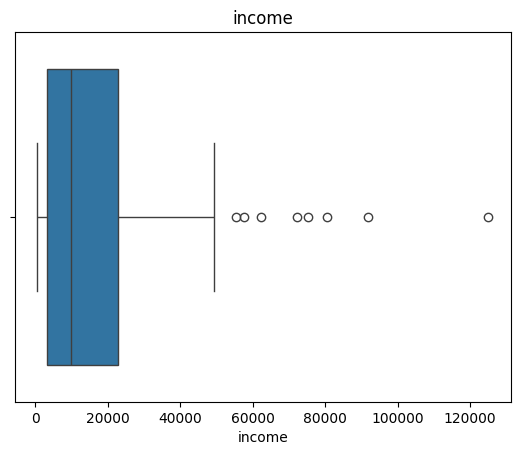

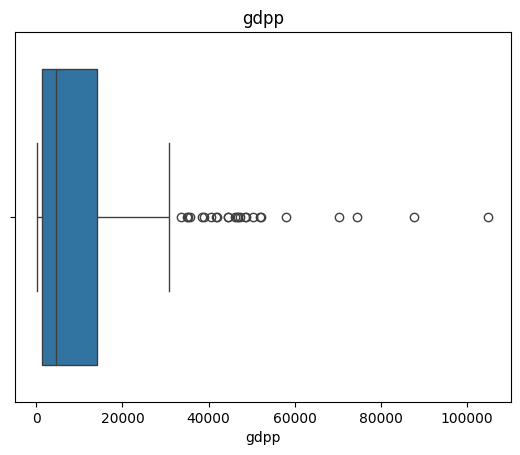

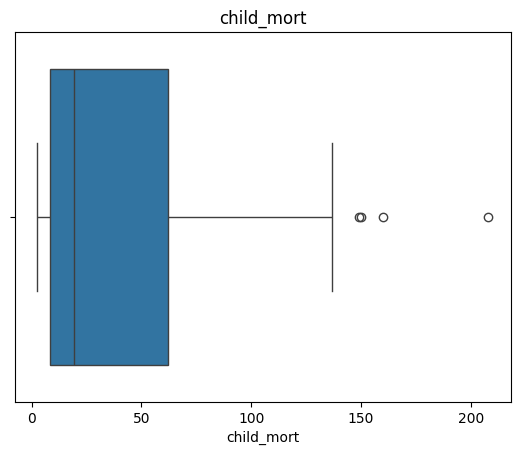

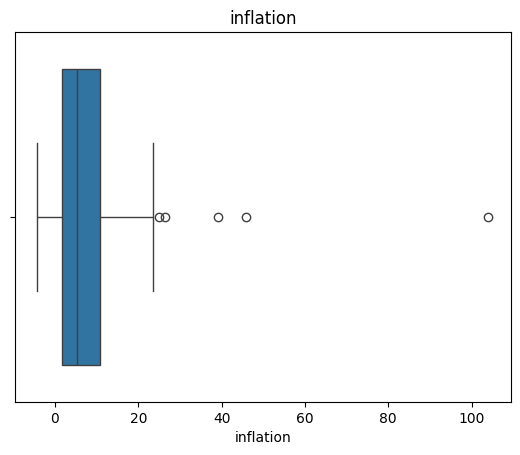

In [ ]:

cols = ['income', 'gdpp', 'child_mort', 'inflation']

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

for col in ['income', 'gdpp', 'child_mort', 'inflation']:
    cap_outliers(col)

In [ ]:

df['inflation'] = df['inflation'].apply(lambda x: x if x >= 0 else df['inflation'].median())

df['inflation'] = df['inflation'].clip(upper=df['inflation'].quantile(0.99))

In [ ]:

df[['income','gdpp','child_mort','inflation']].describe()

(df[['income','gdpp','child_mort']] < 0).sum()



,0
income,0
gdpp,0
child_mort,0


In [ ]:
# Feature Engineering
df['Development_Index'] = (df['income'] + df['gdpp'] + df['life_expec']) / df['child_mort']

df['Trade_Balance'] = df['exports'] - df['imports']

df['Health_Impact_Ratio'] = df['health'] / df['child_mort']

# Segmentation
def segment(row):
    if row['child_mort'] > 80 and row['income'] < 5000:
        return 'High Risk'
    elif row['income'] > 30000 and row['life_expec'] > 78:
        return 'Developed'
    elif 8000 <= row['income'] <= 30000:
        return 'Emerging'
    elif row['inflation'] > 15:
        return 'High Inflation'
    elif row['health'] < 5 and row['child_mort'] > 70:
        return 'Health Critical'
    elif row['gdpp'] < 2000:
        return 'Low GDP'
    else:
        return 'Other'

df['segment'] = df.apply(segment, axis=1)

df['segment'].value_counts()


,count
segment,
Emerging,64
High Risk,26
Developed,26
Other,19
Low GDP,17
High Inflation,14
Health Critical,1


In [ ]:
# Cleaned Excel File
df.to_csv("cleaned_country_data.csv", index=False)

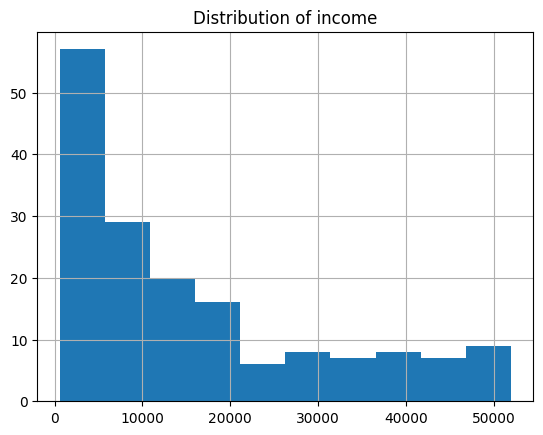

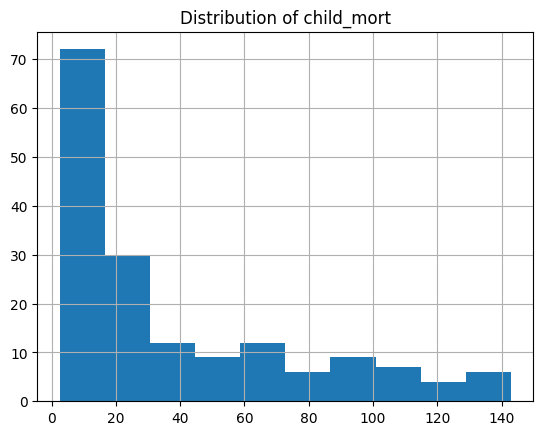

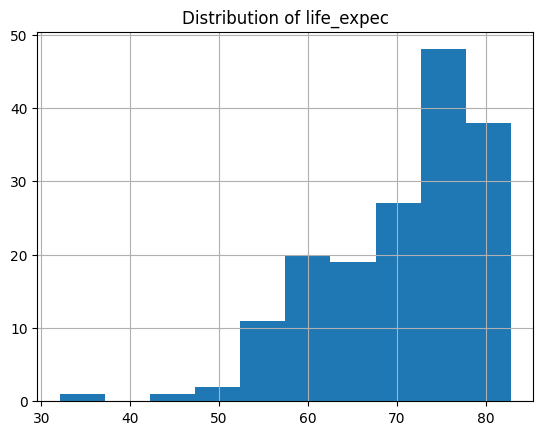

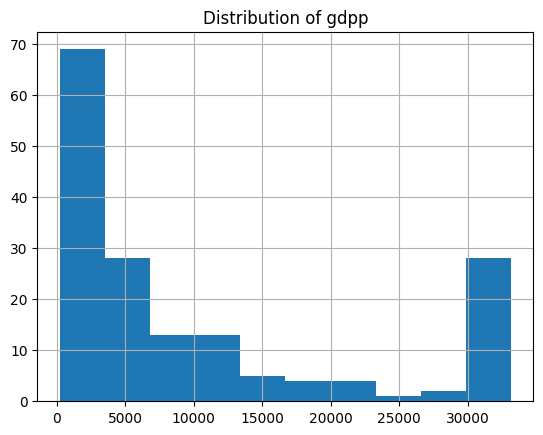

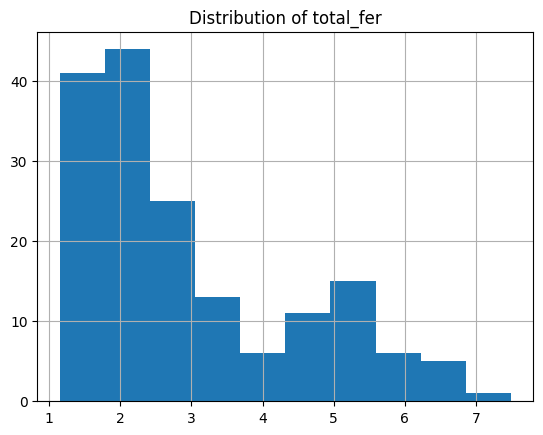

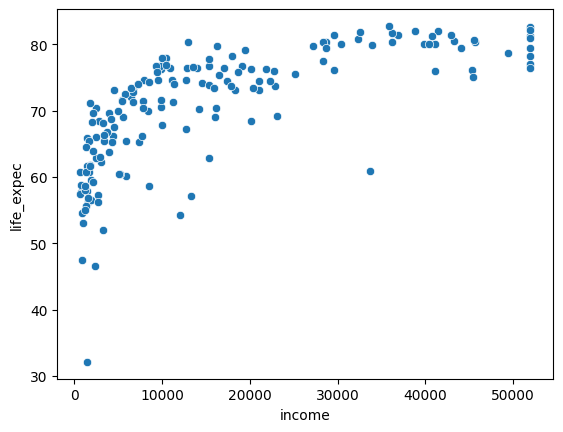

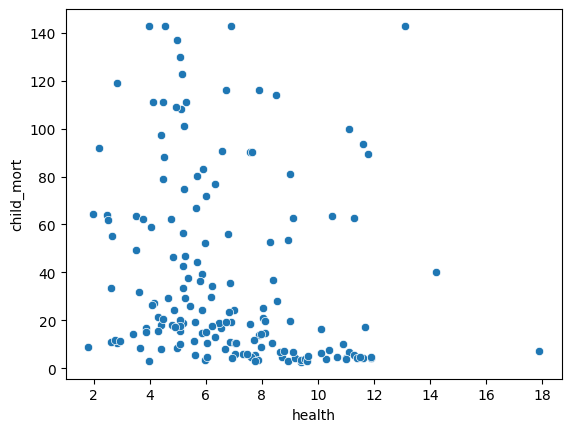

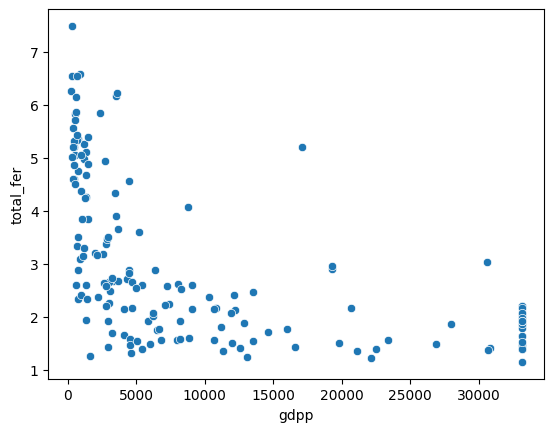

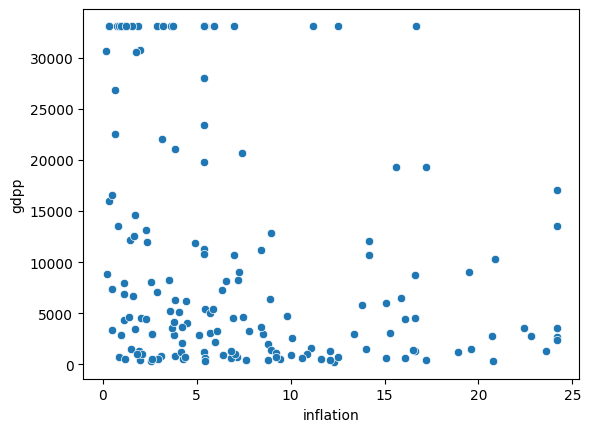

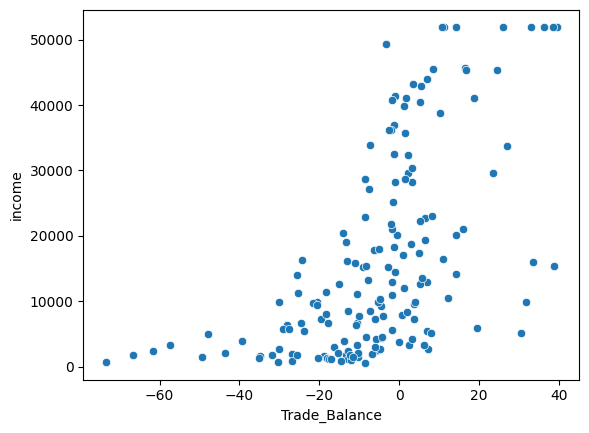

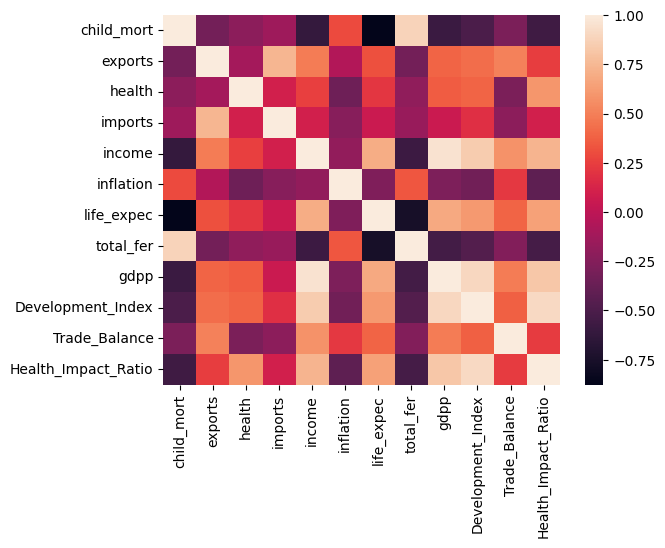

In [ ]:
# EDA

# UNIVARIATE
cols = ['income', 'child_mort', 'life_expec', 'gdpp', 'total_fer']

for col in cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.show()

# BIVARIATE

sns.scatterplot(x='income', y='life_expec', data=df)
plt.show()

sns.scatterplot(x='health', y='child_mort', data=df)
plt.show()

sns.scatterplot(x='gdpp', y='total_fer', data=df)
plt.show()

sns.scatterplot(x='inflation', y='gdpp', data=df)
plt.show()

sns.scatterplot(x='Trade_Balance', y='income', data=df)
plt.show()

# MULTIVARIATE
# Exclude non-numeric columns like 'country' and 'segment' before calculating correlation
sns.heatmap(df.drop(['country', 'segment'], axis=1).corr(), annot=False)
plt.show()

In [ ]:
# Python Segmentation
def segment(row):
    if row['child_mort'] > 80 and row['income'] < 5000:
        return 'High Risk Country'
    elif row['income'] > 30000 and row['life_expec'] > 78:
        return 'Developed Nation'
    elif 8000 <= row['income'] <= 30000:
        return 'Emerging Economy'
    elif row['inflation'] > 15:
        return 'High Inflation Risk'
    elif row['health'] < 5 and row['child_mort'] > 70:
        return 'Health Critical'
    elif row['gdpp'] < 2000:
        return 'Low GDP Trap'
    else:
        return 'Other'

df['segment'] = df.apply(segment, axis=1)

df.to_csv("cleaned_country_data.csv", index=False)

In [ ]:
df['segment'].value_counts()

,count
segment,
Emerging Economy,64
High Risk Country,26
Developed Nation,26
Other,19
Low GDP Trap,17
High Inflation Risk,14
Health Critical,1
